In [ ]:
# Install Kaggle API
!pip install -q kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("derrickmwiti/google-2019-cluster-sample")

print("Path to dataset files:", path)

100%|██████████| 96.7M/96.7M [00:00<00:00, 210MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/derrickmwiti/google-2019-cluster-sample/versions/1


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import Sequential, layers
from tensorflow.keras.utils import plot_model
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

https://research.google/resources/datasets/?search=google+cluster+data&

In [ ]:
data = pd.read_csv('/root/.cache/kagglehub/datasets/derrickmwiti/google-2019-cluster-sample/versions/1/borg_traces_data.csv')
data.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       405894 non-null  int64  
 1   time                             405894 non-null  int64  
 2   instance_events_type             405894 non-null  int64  
 3   collection_id                    405894 non-null  int64  
 4   scheduling_class                 405894 non-null  int64  
 5   collection_type                  405894 non-null  int64  
 6   priority                         405894 non-null  int64  
 7   alloc_collection_id              405894 non-null  int64  
 8   instance_index                   405894 non-null  int64  
 9   machine_id                       405894 non-null  int64  
 10  resource_request                 405120 non-null  object 
 11  constraint                       405894 non-null  object 
 12  co

In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
time,0
instance_events_type,0
collection_id,0
scheduling_class,0
collection_type,0
priority,0
alloc_collection_id,0
instance_index,0
machine_id,0


In [ ]:
data.drop('Unnamed: 0', axis=1, inplace=True)
data = data.select_dtypes(exclude=['object'])
data.dropna(inplace=True)
data = data[data.columns.drop(list(data.filter(like='_id')))]

data.shape

(280897, 18)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280897 entries, 2 to 405892
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             280897 non-null  int64  
 1   instance_events_type             280897 non-null  int64  
 2   scheduling_class                 280897 non-null  int64  
 3   collection_type                  280897 non-null  int64  
 4   priority                         280897 non-null  int64  
 5   instance_index                   280897 non-null  int64  
 6   collections_events_type          280897 non-null  int64  
 7   vertical_scaling                 280897 non-null  float64
 8   scheduler                        280897 non-null  float64
 9   start_time                       280897 non-null  int64  
 10  end_time                         280897 non-null  int64  
 11  assigned_memory                  280897 non-null  float64
 12  page_ca

array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'instance_events_type'}>,
        <Axes: title={'center': 'scheduling_class'}>,
        <Axes: title={'center': 'collection_type'}>],
       [<Axes: title={'center': 'priority'}>,
        <Axes: title={'center': 'instance_index'}>,
        <Axes: title={'center': 'collections_events_type'}>,
        <Axes: title={'center': 'vertical_scaling'}>],
       [<Axes: title={'center': 'scheduler'}>,
        <Axes: title={'center': 'start_time'}>,
        <Axes: title={'center': 'end_time'}>,
        <Axes: title={'center': 'assigned_memory'}>],
       [<Axes: title={'center': 'page_cache_memory'}>,
        <Axes: title={'center': 'cycles_per_instruction'}>,
        <Axes: title={'center': 'memory_accesses_per_instruction'}>,
        <Axes: title={'center': 'sample_rate'}>],
       [<Axes: title={'center': 'cluster'}>,
        <Axes: title={'center': 'failed'}>, <Axes: >, <Axes: >]],
      dtype=object)

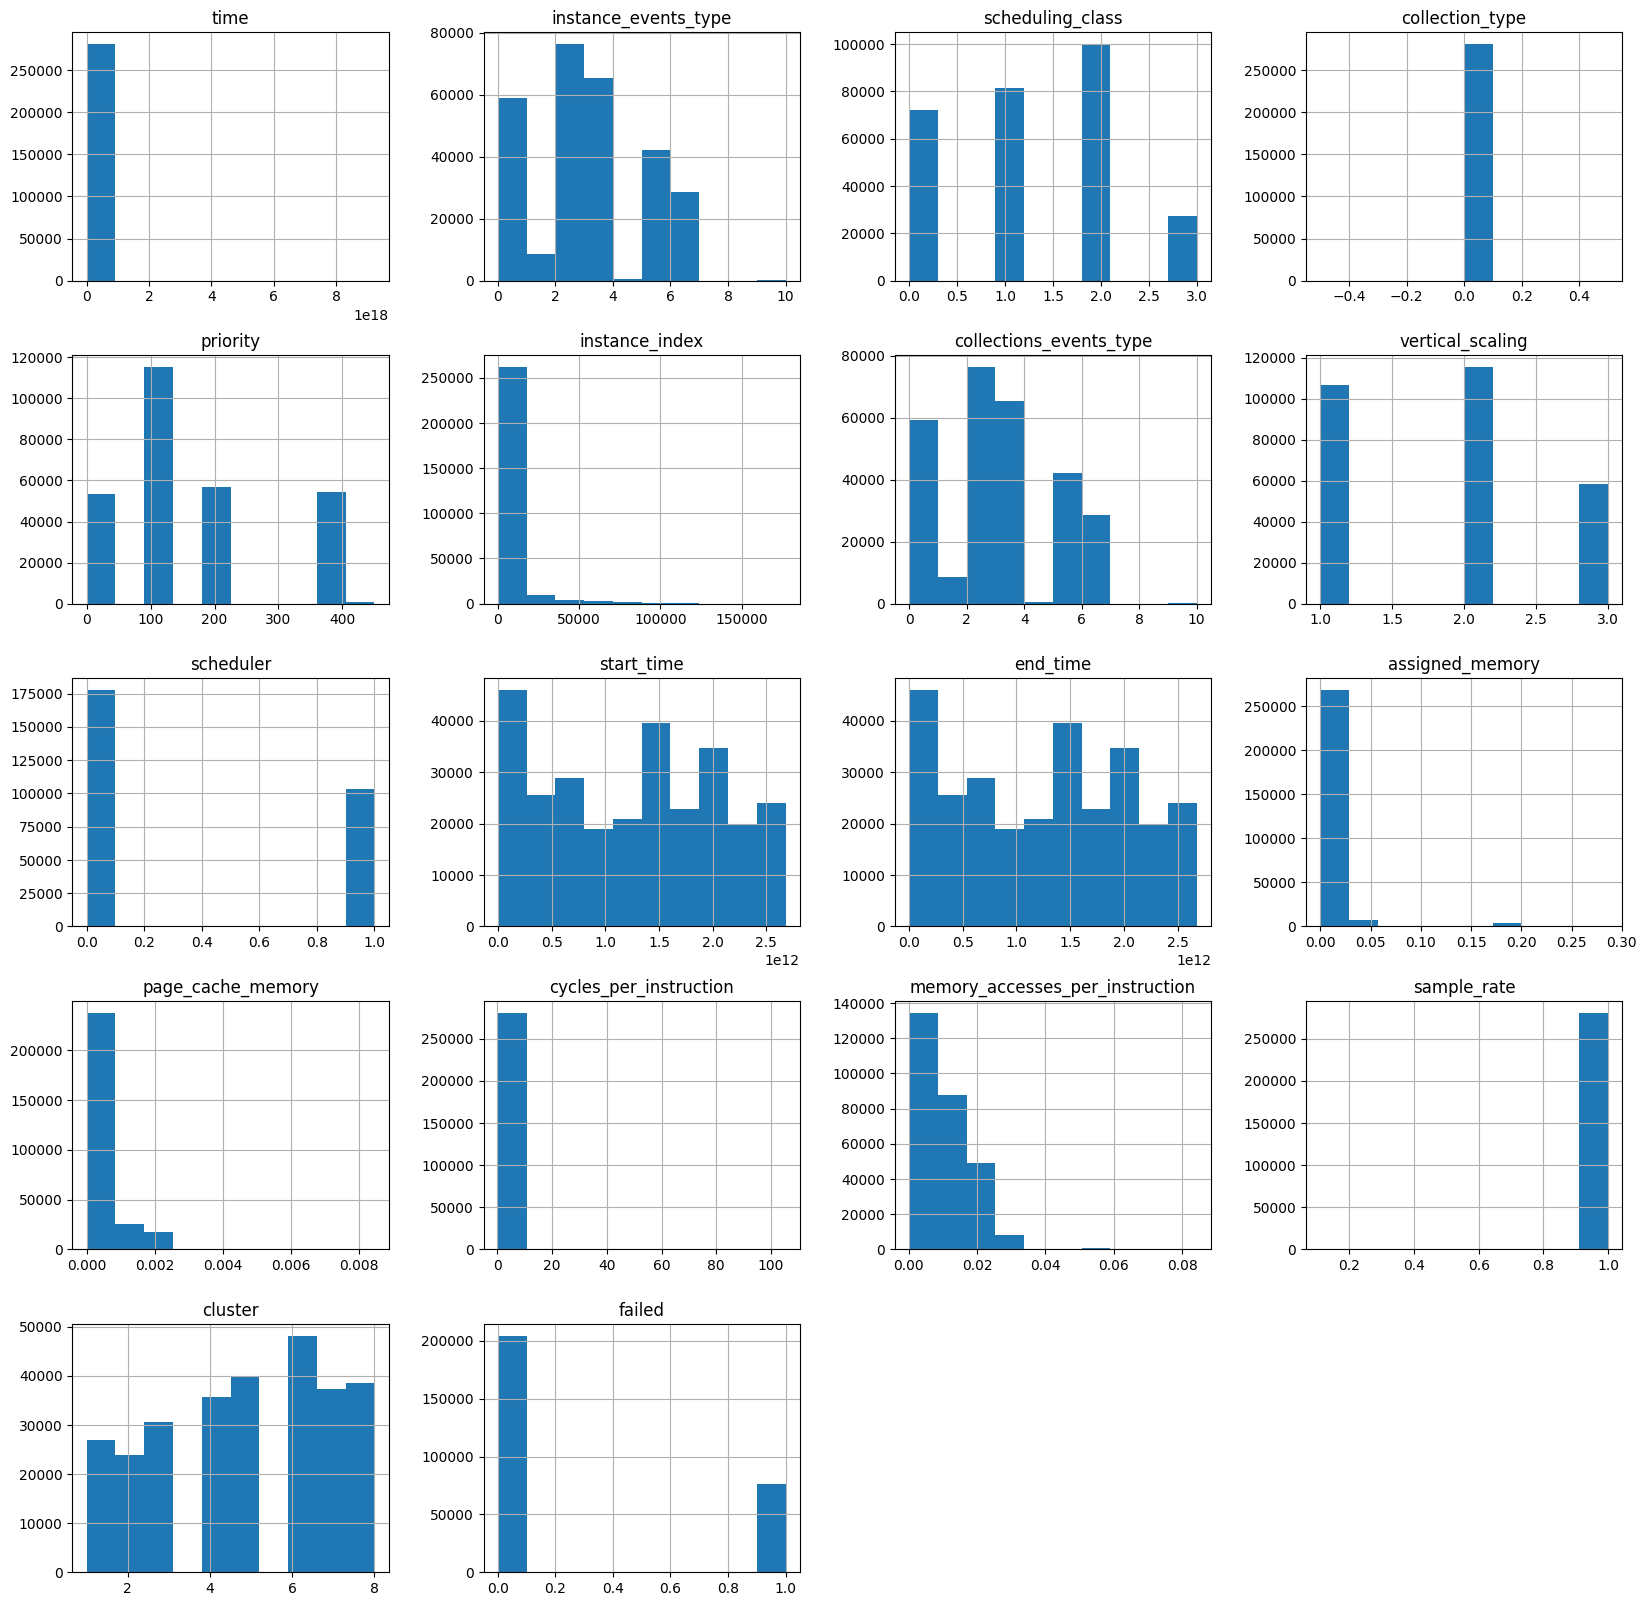

In [ ]:
# can we give figuer different color for comparisaion reason
data.hist(figsize=(20,20))

In [ ]:
data.head()

,time,instance_events_type,scheduling_class,collection_type,priority,instance_index,collections_events_type,vertical_scaling,scheduler,start_time,end_time,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cluster,failed
2,195684022913,6,2,0,103,376,6,2.0,1.0,81300000000,81600000000,0.010422,2.346039e-04,0.939919,0.001318,1.0,7,0
3,0,2,3,0,200,1977,2,2.0,0.0,1075500000000,1075800000000,0.041626,2.250671e-04,1.359102,0.007643,1.0,8,1
6,130721370174,0,1,0,117,13138,0,1.0,0.0,343800000000,344100000000,0.002190,5.722046e-06,0.646689,0.007937,1.0,7,0
7,2373350421416,3,2,0,103,393,3,2.0,1.0,455400000000,455700000000,0.001474,5.912781e-05,1.767994,0.017505,1.0,7,0
8,1970214287222,0,0,0,0,19760,0,1.0,0.0,2249100000000,2249400000000,0.006683,9.536743e-07,3.492855,0.009506,1.0,5,0


In [ ]:
def check_outlier(DataFrame):
    # DataFrame.hist(figsize=(10,10))
    dic = {}
    for i in DataFrame:
        Q1 = DataFrame[i].quantile(0.25)
        Q3 = DataFrame[i].quantile(0.75)
        IQR = Q3-Q1
        up = Q3 + 1.5*IQR
        low = Q1 - 1.5*IQR

        if DataFrame[(DataFrame[i] > up) | (DataFrame[i] < low)].any(axis=None):
            dic[i] = 1
        else:
            dic[i] = 0
    return pd.Series(dic)

check_outlier(data)

,0
time,1
instance_events_type,1
scheduling_class,0
collection_type,0
priority,1
instance_index,1
collections_events_type,1
vertical_scaling,0
scheduler,0
start_time,0


In [ ]:
def outlier_solver(DataFrame):
    for i in DataFrame:
        Q1 = DataFrame[i].quantile(0.25)
        Q3 = DataFrame[i].quantile(0.75)
        IQR = Q3 - Q1
        up_lim  = Q3 + 1.5 * IQR
        low_lim = Q1 - 1.5 * IQR
        DataFrame.loc[DataFrame[i] > up_lim,i]  = up_lim
        DataFrame.loc[DataFrame[i] < low_lim,i] = low_lim
    return check_outlier(DataFrame)

outlier_solver(data)

<ipython-input-15-49df7b594e1f>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4133540222603.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  DataFrame.loc[DataFrame[i] > up_lim,i] = up_lim
<ipython-input-15-49df7b594e1f>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  DataFrame.loc[DataFrame[i] > up_lim,i] = up_lim
<ipython-input-15-49df7b594e1f>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '345.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  DataFrame.loc[DataFrame[i] > up_lim,i] = up_lim
<ipython-input-15-49df7b594e1f>:8: FutureWarning: Setting an item of

,0
time,0
instance_events_type,0
scheduling_class,0
collection_type,0
priority,0
instance_index,0
collections_events_type,0
vertical_scaling,0
scheduler,0
start_time,0


array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'instance_events_type'}>,
        <Axes: title={'center': 'scheduling_class'}>,
        <Axes: title={'center': 'collection_type'}>],
       [<Axes: title={'center': 'priority'}>,
        <Axes: title={'center': 'instance_index'}>,
        <Axes: title={'center': 'collections_events_type'}>,
        <Axes: title={'center': 'vertical_scaling'}>],
       [<Axes: title={'center': 'scheduler'}>,
        <Axes: title={'center': 'start_time'}>,
        <Axes: title={'center': 'end_time'}>,
        <Axes: title={'center': 'assigned_memory'}>],
       [<Axes: title={'center': 'page_cache_memory'}>,
        <Axes: title={'center': 'cycles_per_instruction'}>,
        <Axes: title={'center': 'memory_accesses_per_instruction'}>,
        <Axes: title={'center': 'sample_rate'}>],
       [<Axes: title={'center': 'cluster'}>,
        <Axes: title={'center': 'failed'}>, <Axes: >, <Axes: >]],
      dtype=object)

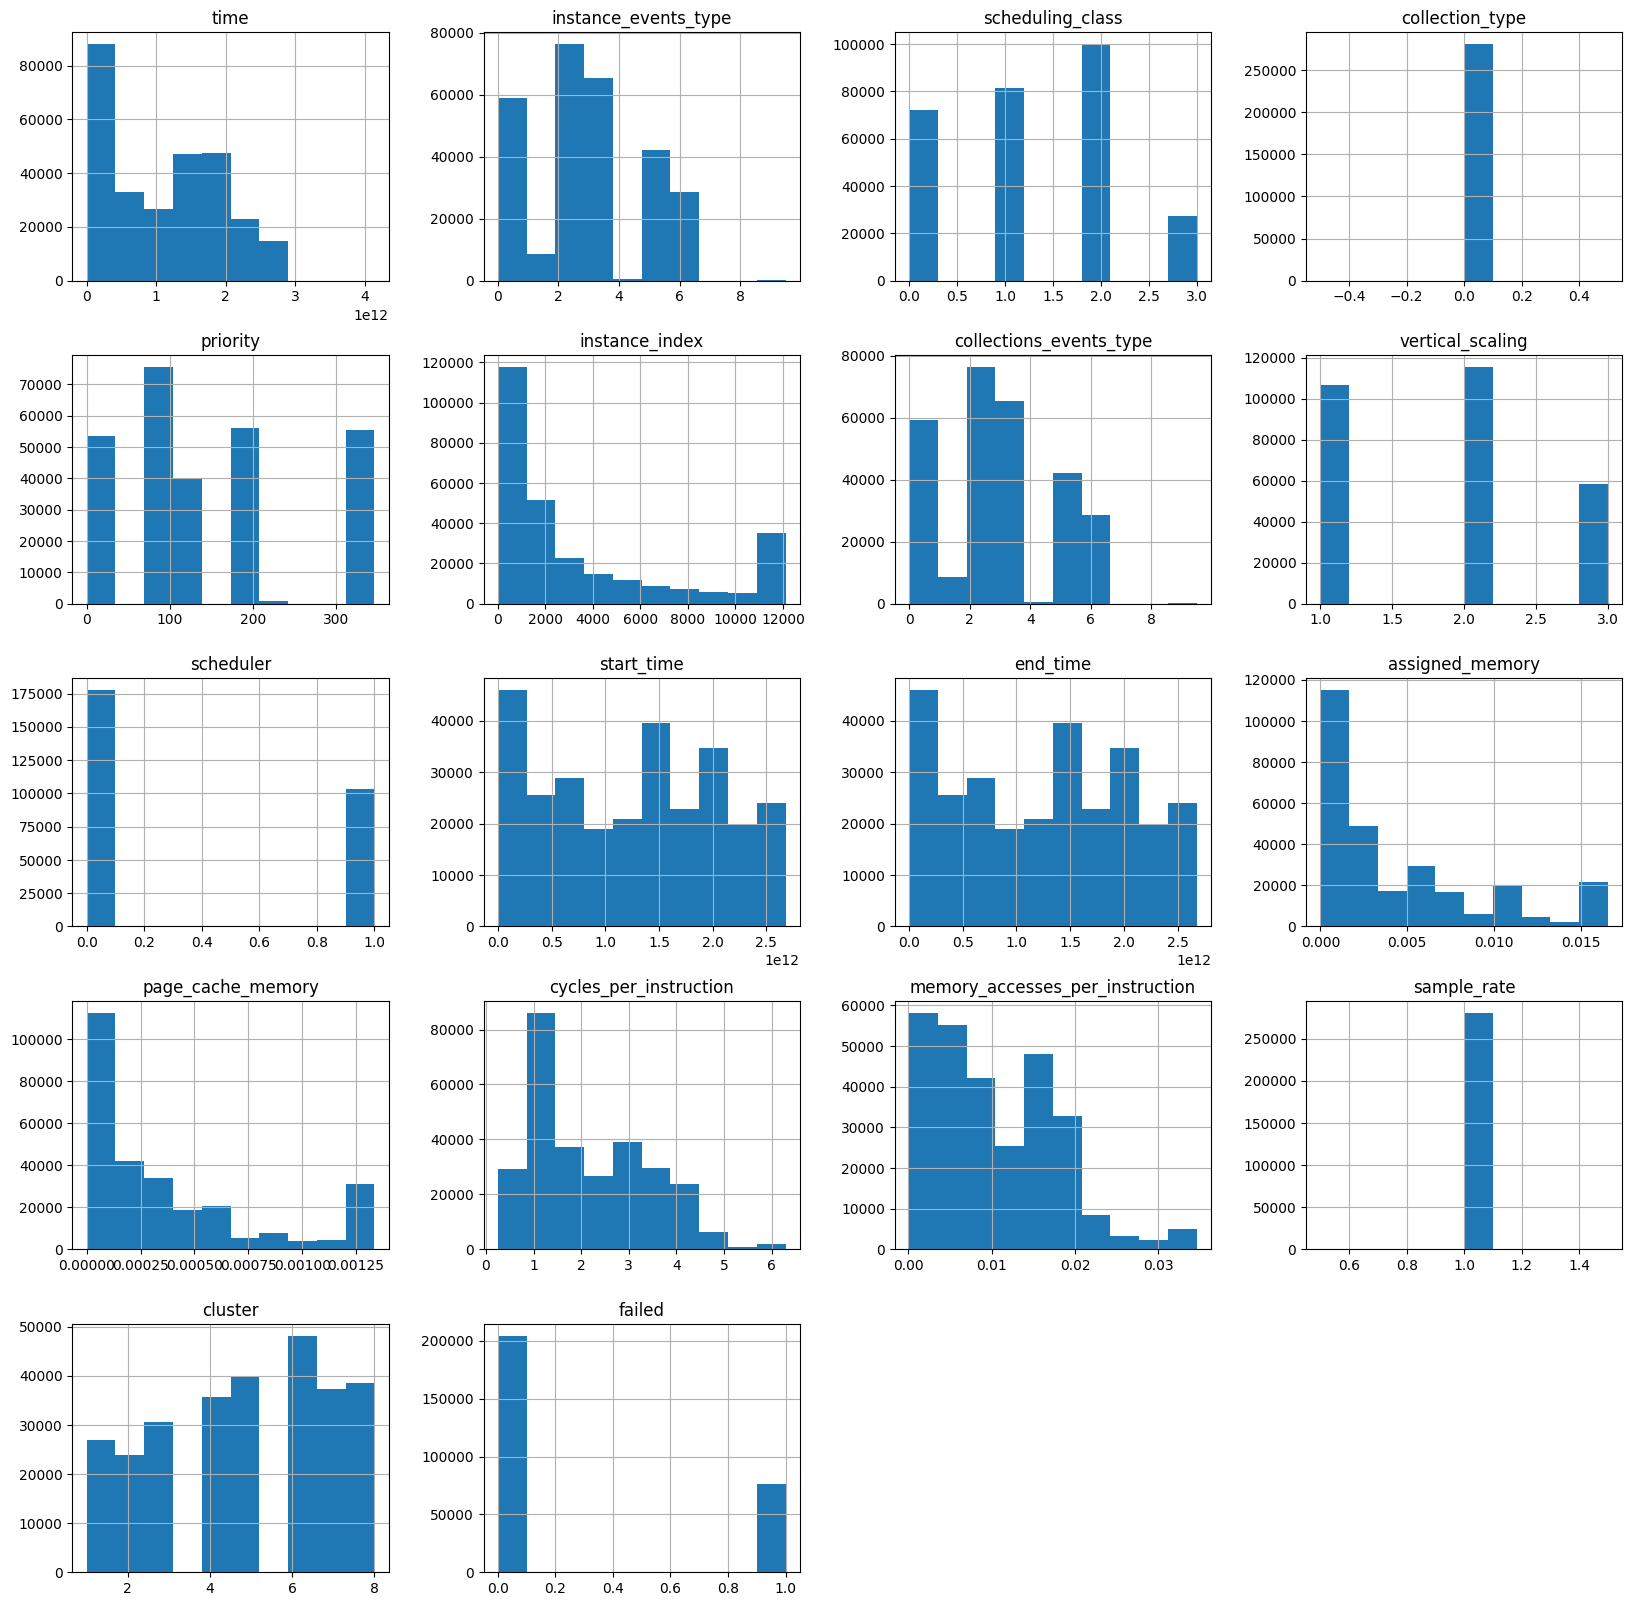

In [ ]:
data.hist(figsize=(20,20))

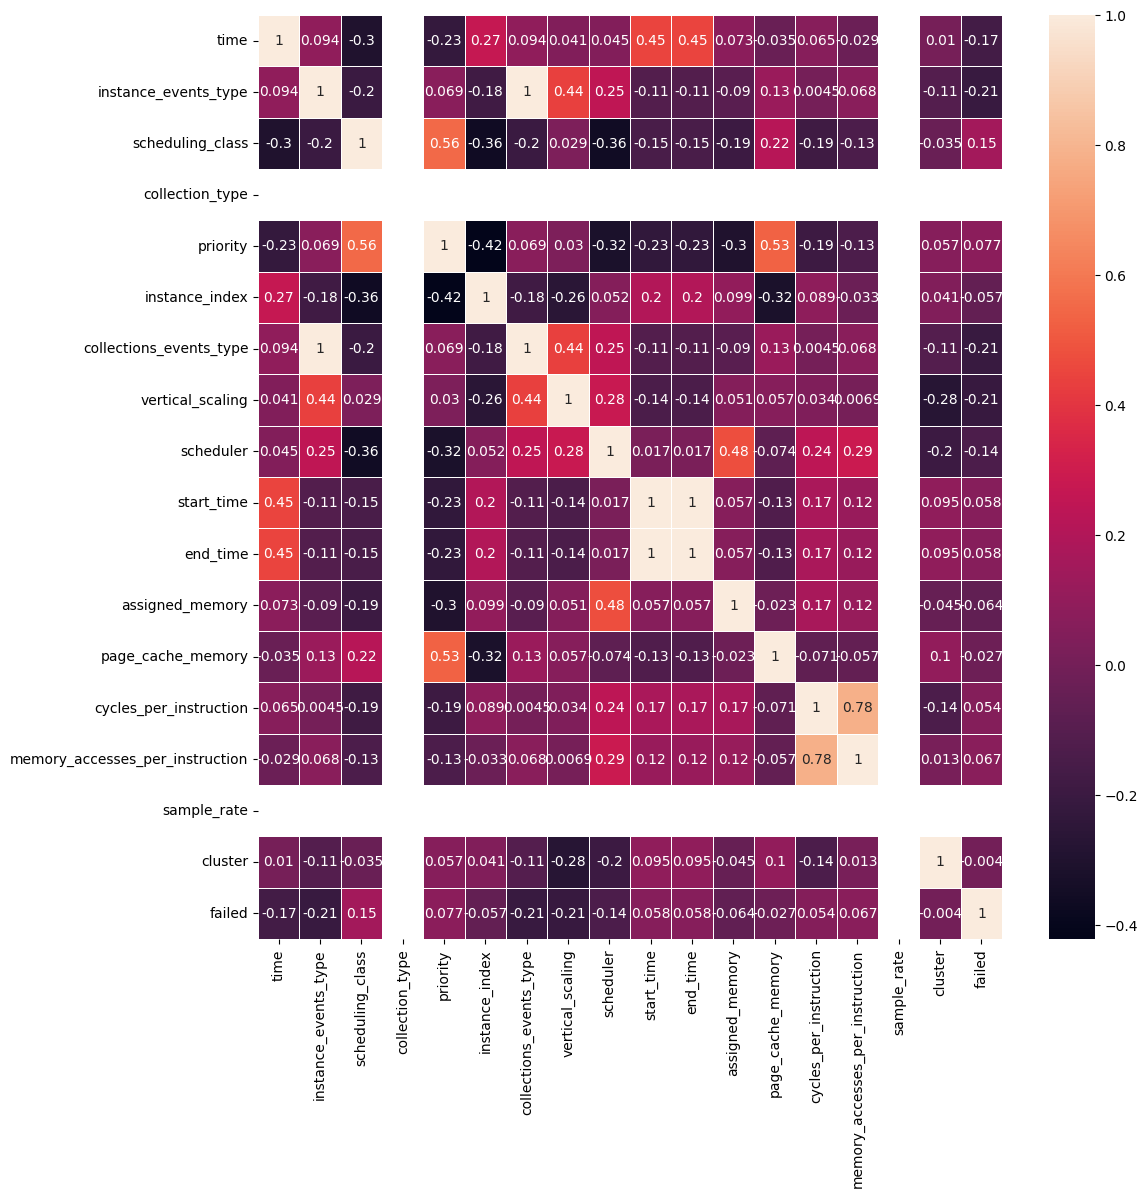

In [ ]:
def Correlation_figure(DataFrame):
    plt.figure(figsize=(12,12))
    sns.heatmap(DataFrame.corr(),annot=True,linewidths=0.6)

Correlation_figure(data)

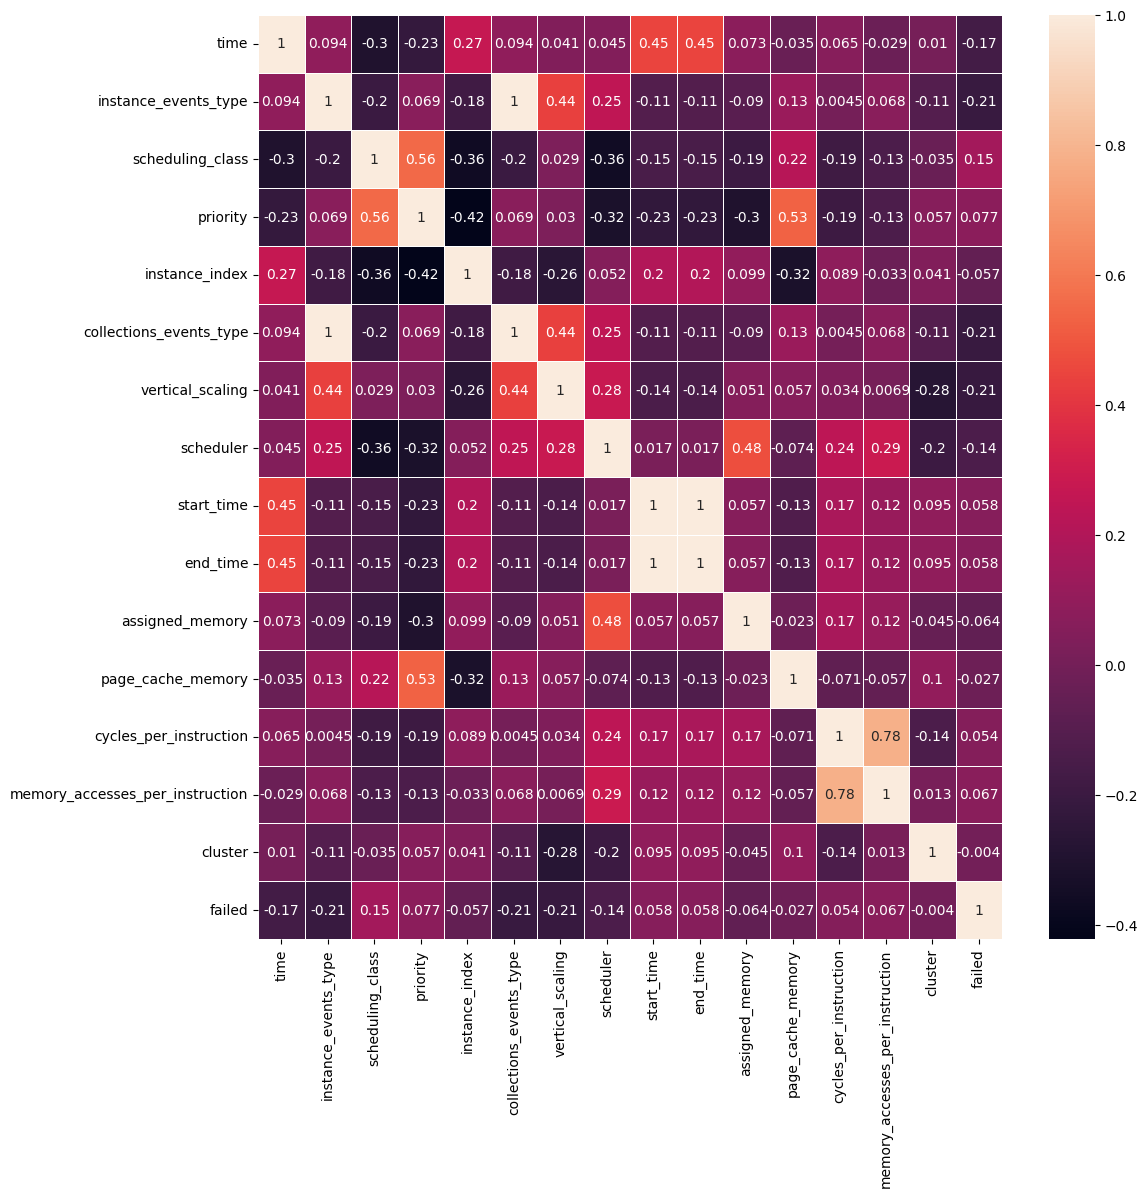

In [ ]:
data.drop(['collection_type','sample_rate'], axis=1, inplace=True)
Correlation_figure(data)

<Axes: xlabel='cluster', ylabel='count'>

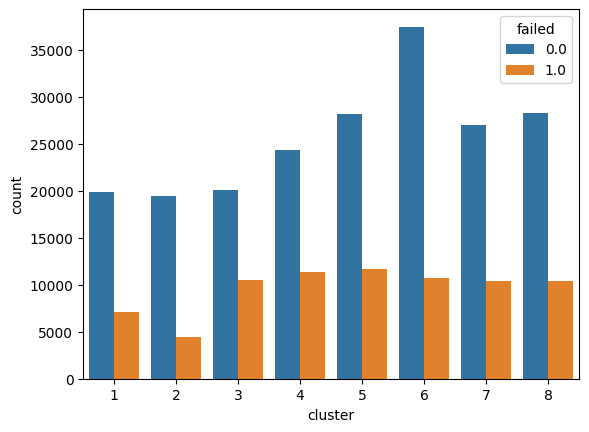

In [ ]:
sns.countplot(data, x="cluster", hue="failed")

<Axes: xlabel='cluster', ylabel='time'>

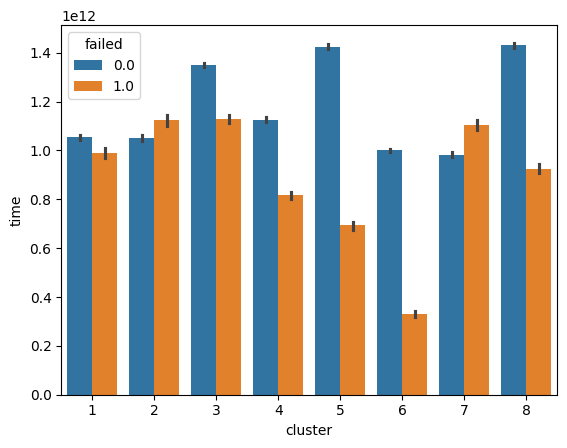

In [ ]:
sns.barplot(data, x="cluster", y="time", hue="failed")

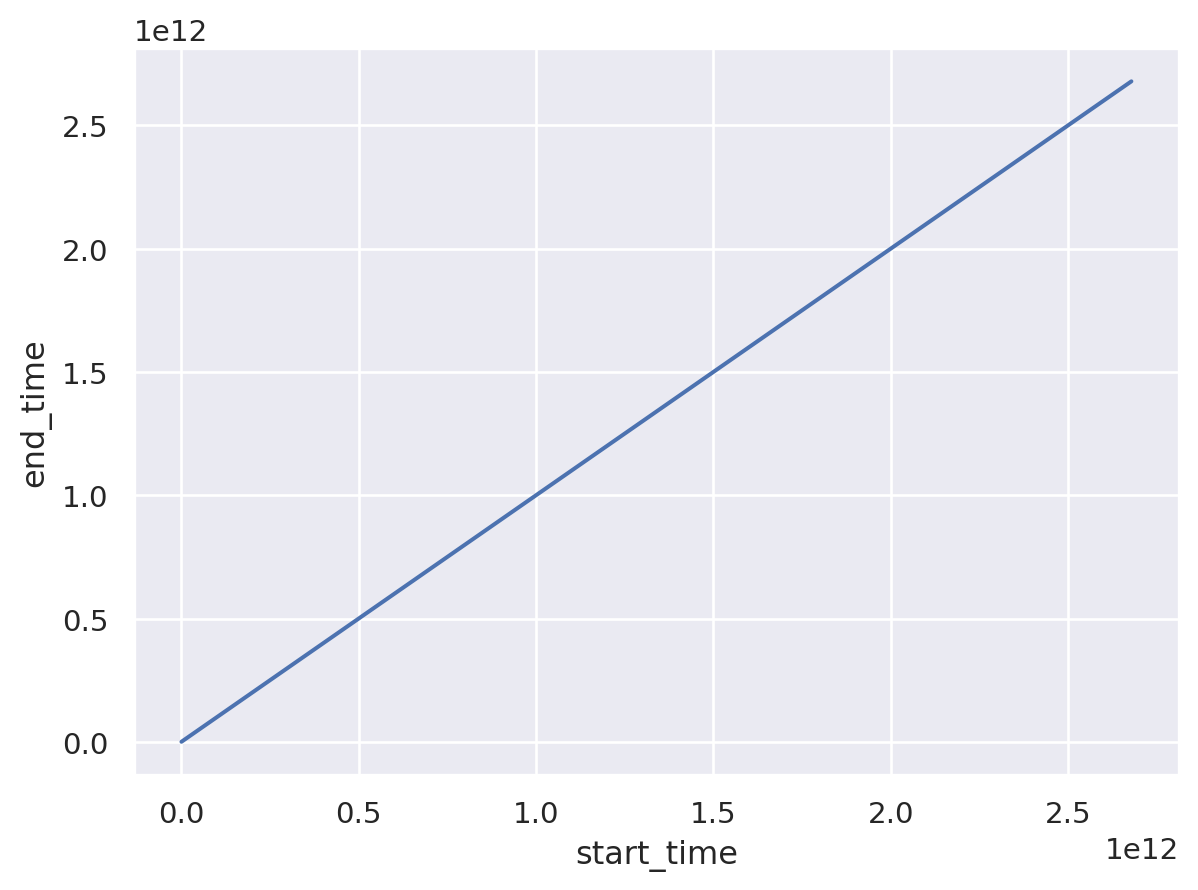

In [ ]:
so.Plot(data, "start_time", "end_time").add(so.Line())

In [ ]:
X = data.drop(['cluster','failed'], axis=1, inplace=False)
y = keras.utils.to_categorical(data.loc[:,'cluster'])
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.9, random_state=42, shuffle=True)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


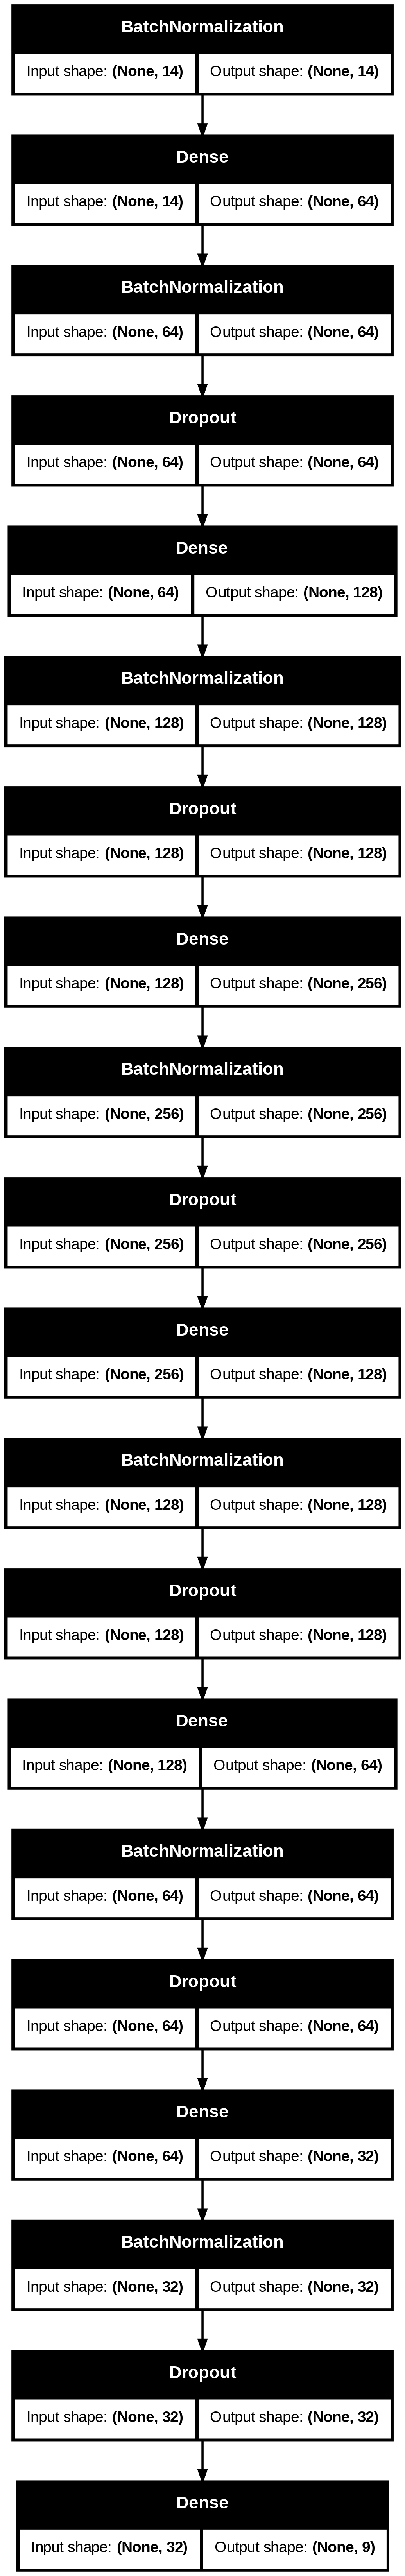

In [ ]:
input_shape  = [X.shape[1]]
output_shape = y.shape[1]

model = keras.Sequential([
    # input layer
    layers.BatchNormalization(input_shape=input_shape),

    # hidden layer
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    # hidden layer
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    # hidden layer
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # hidden layer
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    # hidden layer
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    # hidden layer
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # output layer
    layers.Dense(output_shape, activation='softmax')
])

plot_model(model, show_shapes = True)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 24s 420ms/step - accuracy: 0.2441 - loss: 2.2751 - val_accuracy: 0.2625 - val_loss: 2.0962
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4809 - loss: 1.5327 - val_accuracy: 0.2706 - val_loss: 2.0167
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5503 - loss: 1.3365 - val_accuracy: 0.3228 - val_loss: 1.9325
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5895 - loss: 1.2172 - val_accuracy: 0.3639 - val_loss: 1.7683
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6132 - loss: 1.1372 - val_accuracy: 0.4400 - val_loss: 1.5946
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6355 - loss: 1.0679 - val_accuracy: 0.5407 - val_loss: 1.4070
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6532 - loss: 1.0132 - val_accuracy: 0.5625 - val_loss: 1.2801
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6696 - loss: 0.9618 - val_accuracy: 0.6201 -

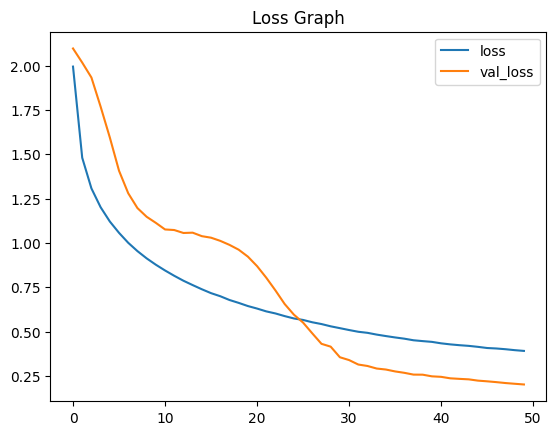

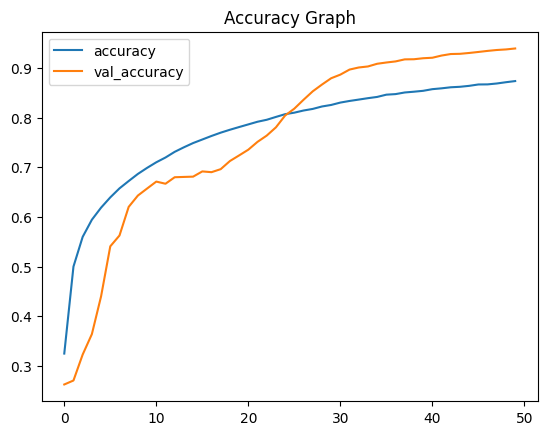

In [ ]:
def Model_Evaluation(model, X_train, y_train, X_valid, y_valid):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    early_stopping = keras.callbacks.EarlyStopping(patience=5, min_delta=0.001, restore_best_weights=True,)

    history = model.fit(
        X_train, y_train,
        validation_data = (X_valid, y_valid),
        batch_size= 10000,
        epochs = 50,
        callbacks=[early_stopping],
    )

    history_df = pd.DataFrame(history.history)
    history_df.loc[:, ['loss', 'val_loss']].plot(title="Loss Graph")
    history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy Graph")

Model_Evaluation(model, X_train, y_train, X_valid, y_valid)

In [ ]:
def ConfM(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()

In [ ]:
y_log = data.loc[:,'failed']

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.1, random_state=42, shuffle=True)

In [ ]:
def ClassificationModel(model, X_train, X_test, y_train, y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    ConfM(y_test, y_pred)

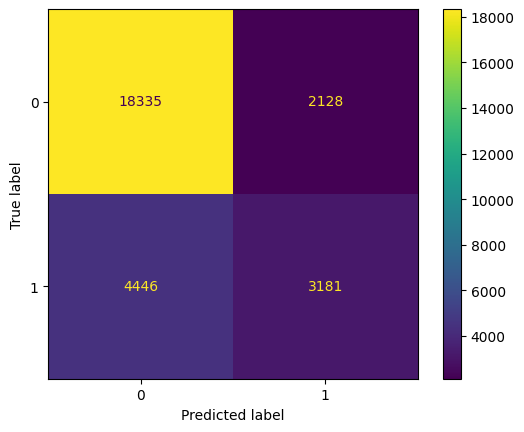

In [ ]:
LogisticRegressionModel = LogisticRegression(penalty='l2', solver='liblinear', C=1, random_state=42, max_iter=10000)
ClassificationModel(LogisticRegressionModel, X_train, X_test, y_train, y_test)

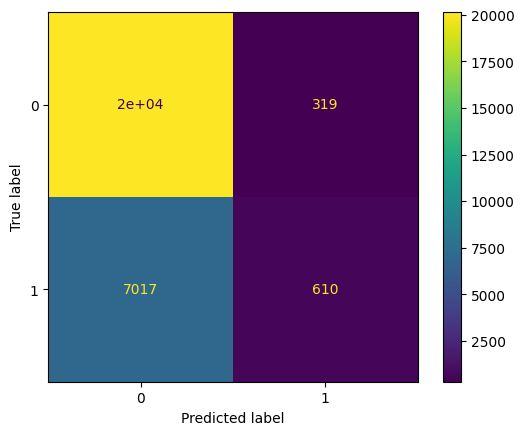

In [ ]:
SGDClassifierModel = SGDClassifier(penalty='l2', random_state=42, max_iter=10000, loss='perceptron', learning_rate='optimal')
ClassificationModel(SGDClassifierModel, X_train, X_test, y_train, y_test)

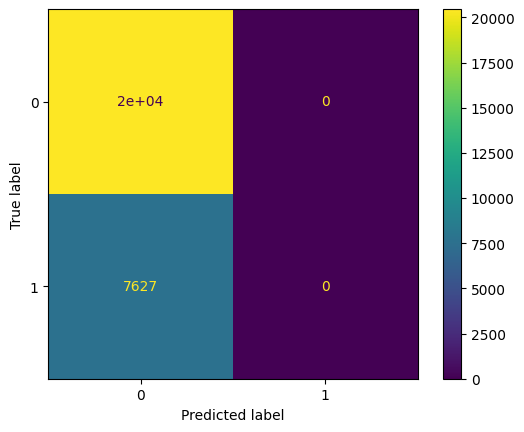

In [ ]:
MLPClassifierModel = MLPClassifier(hidden_layer_sizes=(100,3),
                      activation='tanh',
                      solver='adam',
                      alpha=0.0001,
                      learning_rate_init=0.001,
                      max_iter=200,
                      random_state=42,
                      early_stopping = False
                     )
ClassificationModel(MLPClassifierModel, X_train, X_test, y_train, y_test)